#  Next Word Prediction using Deep Learning (LSTM)
### Built with TensorFlow/Keras — Full Pipeline: Data → Train → Predict

This notebook builds an **LSTM-based language model** that predicts the next word in a sentence.

**Pipeline:**
1. Corpus preparation & tokenization
2. N-gram sequence generation
3. LSTM model architecture
4. Training with callbacks
5. Evaluation & prediction
6. Interactive text generation

##  Step 1: Install & Import Libraries

In [1]:
# Install required libraries
!pip install tensorflow numpy matplotlib seaborn ipywidgets -q

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import random
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Embedding, LSTM, Dense, Dropout,
    Bidirectional, BatchNormalization
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau,
    ModelCheckpoint
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 29.3 MB/s eta 0:00:00
TensorFlow version: 2.19.0
GPU available: True


##  Step 2: Prepare the Corpus

In [2]:
corpus_text = """
The sun rises in the east and sets in the west every single day.
Deep learning is a subset of machine learning that uses neural networks.
Neural networks are inspired by the structure of the human brain.
The brain contains billions of neurons that communicate through synapses.
Artificial intelligence is transforming the way we live and work.
Machine learning models learn patterns from data to make predictions.
Natural language processing enables computers to understand human language.
The cat sat on the mat and looked out the window at the birds.
Birds fly south in winter to escape the cold and find food.
The quick brown fox jumps over the lazy dog near the river.
Science and technology are advancing rapidly in the modern world.
Data science combines statistics programming and domain expertise.
Python is a popular programming language for data science and AI.
The history of computer science dates back to the mid twentieth century.
Alan Turing was a pioneer in computer science and artificial intelligence.
The future of artificial intelligence holds great promise and challenges.
Researchers are working on making AI systems more reliable and fair.
Language models are trained on large amounts of text data from the internet.
Text generation models can write poetry stories and even code.
The night sky is filled with millions of stars and distant galaxies.
Space exploration has revealed many secrets about our solar system.
The ocean covers more than seventy percent of the surface of the Earth.
Climate change is one of the most pressing issues of our time.
Renewable energy sources like solar and wind power are growing rapidly.
Education is the foundation of a strong and prosperous society.
Children learn best when they are curious and engaged in their studies.
Reading books expands the mind and opens doors to new worlds.
The power of words can inspire change and move entire nations.
Every great journey begins with a single step toward the destination.
Success comes to those who work hard and never give up on their dreams.
The mountains stand tall and silent as witnesses to the passage of time.
Rivers carve their way through rock and soil on their long journey to the sea.
The forest is home to countless species of plants and animals.
Music is a universal language that connects people across cultures.
Art and creativity are essential expressions of the human spirit.
The human heart pumps blood through the body thousands of times each day.
Medicine has advanced greatly allowing people to live longer healthier lives.
Vaccines have saved millions of lives by preventing deadly diseases.
The internet has connected the world in ways never before imagined.
Social media has changed how people communicate share and consume information.
Computers process information at incredible speeds using binary code.
Algorithms are step by step instructions for solving computational problems.
The study of mathematics is fundamental to all branches of science.
Physics describes the fundamental laws that govern the universe.
Chemistry explores the properties and interactions of matter.
Biology is the science of life and living organisms on Earth.
Ecology studies the relationships between organisms and their environment.
Genetics reveals how traits are inherited from one generation to the next.
Evolution explains the diversity of life through natural selection.
The universe began with the big bang approximately fourteen billion years ago.
Time flows forward and we cannot go back to change the past.
Every moment is an opportunity to learn grow and become better.
Kindness and compassion make the world a more beautiful place to live.
The power of the human mind is truly remarkable and limitless.
"""

# Clean & split into sentences
import re
sentences = [s.strip().lower() for s in corpus_text.strip().split('\n') if len(s.strip()) > 10]
print(f'Total sentences: {len(sentences)}')
print(f'Sample sentences:')
for s in sentences[:3]:
    print(f'  → {s}')

Total sentences: 54
Sample sentences:
  → the sun rises in the east and sets in the west every single day.
  → deep learning is a subset of machine learning that uses neural networks.
  → neural networks are inspired by the structure of the human brain.


##  Step 3: Tokenization & Vocabulary

In [3]:
tokenizer=Tokenizer(oov_token='<OOV>')  # Out-of-Vocabulary token
tokenizer.fit_on_texts(sentences)

vocab_size=len(tokenizer.word_index) + 1
word_index=tokenizer.word_index
index_word=tokenizer.index_word

print(f'Vocabulary size :{vocab_size}')
print(f'Sample word→idx :{ {k: word_index[k] for k in list(word_index)[:8]} }')

#  Build N-gram sequences
input_sequences = [] # Initialize input_sequences
for sentence in sentences:
    token_list = tokenizer.texts_to_sequences([sentence])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

print(f'\nTotal n-gram sequences: {len(input_sequences)}')
print(f'Sample sequences (first 5):')
for seq in input_sequences[:5]:
    words = [index_word[i] for i in seq]
    print(f'  {seq} → {words}')

Vocabulary size :340
Sample word→idx :{'<OOV>': 1, 'the': 2, 'and': 3, 'of': 4, 'to': 5, 'is': 6, 'are': 7, 'in': 8}

Total n-gram sequences: 544
Sample sequences (first 5):
  [2, 79] → ['the', 'sun']
  [2, 79, 80] → ['the', 'sun', 'rises']
  [2, 79, 80, 8] → ['the', 'sun', 'rises', 'in']
  [2, 79, 80, 8, 2] → ['the', 'sun', 'rises', 'in', 'the']
  [2, 79, 80, 8, 2, 81] → ['the', 'sun', 'rises', 'in', 'the', 'east']


##  Step 4: Pad Sequences & Create Training Data

In [4]:
#  Pad sequences to uniform length
max_seq_len=max(len(x) for x in input_sequences)
print(f'Max sequence length: {max_seq_len}')
padded_sequences=pad_sequences(
    input_sequences,
    maxlen=max_seq_len,
    padding='pre'
)

#  Split features (X) and labels (y)
X=padded_sequences[:, :-1]   # all tokens except last
y=padded_sequences[:, -1]    # last token = label

# One-hot encode labels
y=to_categorical(y, num_classes=vocab_size)

print(f'\nX shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Sample X[0]: {X[0]}')
print(f'Sample y[0] (top indices): {np.where(y[0] > 0)}')

Max sequence length: 15

X shape: (544, 14)
y shape: (544, 340)
Sample X[0]: [0 0 0 0 0 0 0 0 0 0 0 0 0 2]
Sample y[0] (top indices): (array([79]),)


##  Step 5: Build the LSTM Model

In [5]:
# Model Configuration
EMBEDDING_DIM=100
LSTM_UNITS_1=256
LSTM_UNITS_2=128
DROPOUT_RATE=0.3
LEARNING_RATE=0.001

def build_model(vocab_size, max_seq_len, embedding_dim, lstm1, lstm2, dropout):
    model=Sequential([
        #Embedding Layer
        Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            input_length=max_seq_len - 1,
            name='embedding'
        ),

        #  Bidirectional LSTM Layer 1
        Bidirectional(
            LSTM(lstm1, return_sequences=True, dropout=dropout),
            name='biLSTM_1'
        ),
        BatchNormalization(),

        #  LSTM Layer 2
        LSTM(lstm2, dropout=dropout, name='LSTM_2'),
        BatchNormalization(),

        #  Dense Layers
        Dense(256, activation='relu', name='dense_1'),
        Dropout(dropout),

        # Output Layer
        Dense(vocab_size, activation='softmax', name='output')
    ])

    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model=build_model(
    vocab_size, max_seq_len,
    EMBEDDING_DIM, LSTM_UNITS_1, LSTM_UNITS_2, DROPOUT_RATE
)

model.summary()
print(f'\nTotal parameters: {model.count_params():,}')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ biLSTM_1 (Bidirectional)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

ValueError: You tried to call `count_params` on layer 'sequential', but the layer isn't built. You can build it manually via: `layer.build(input_shape)`.

##  Step 6: Train the Model

In [6]:
# Callbacks
callbacks=[
    EarlyStopping(
        monitor='loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        'best_model.h5',
        monitor='accuracy',
        save_best_only=True,
        verbose=0
    )
]

#  Train
EPOCHS=100
BATCH_SIZE=64

print('Starting training...')
history=model.fit(
    X, y,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

print(f'\nTraining complete!')
print(f'Final Loss    : {history.history["loss"][-1]:.4f}')
print(f'Final Accuracy: {history.history["accuracy"][-1]:.4f}')

Starting training...
Epoch 1/100
7/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0138 - loss: 6.0422

9/9 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step - accuracy: 0.0129 - loss: 5.9684 - learning_rate: 0.0010
Epoch 2/100
7/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.0568 - loss: 5.4979

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.0496 - loss: 5.4766 - learning_rate: 0.0010
Epoch 3/100
7/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.0782 - loss: 5.1515

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.0809 - loss: 5.1494 - learning_rate: 0.0010
Epoch 4/100
7/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0812 - loss: 4.8925

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.0901 - loss: 4.8655 - learning_rate: 0.0010
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1215 - loss: 4.6117

...

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9614 - loss: 0.1825 - learning_rate: 0.0010
Epoch 51/100
7/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9691 - loss: 0.1650

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9669 - loss: 0.1739 - learning_rate: 0.0010
Epoch 52/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9632 - loss: 0.1745 - learning_rate: 0.0010
Epoch 53/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9614 - loss: 0.1697 - learning_rate: 0.0010
Epoch 54/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9504 - loss: 0.1865 - learning_rate: 0.0010
Epoch 55/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9596 - loss: 0.1686 - learning_rate: 0.0010
Epoch 56/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9651 - loss: 0.1543 - learning_rate: 0.0010
Epoch 57/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9577 - loss: 0.1638 - learning_rate: 0.0010
Epoch 58/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9596 - loss: 0.1643 - learning_rate: 0.0010
Epoch 59/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9540 - loss: 0.1565 - learning_rate: 0.0010
Epoch 60/100
9/9 ━━━━━━━━━━━━━━━

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9688 - loss: 0.1373 - learning_rate: 5.0000e-04
Epoch 65/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9632 - loss: 0.1460 - learning_rate: 5.0000e-04
Epoch 66/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9791 - loss: 0.1130

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9724 - loss: 0.1313 - learning_rate: 5.0000e-04
Epoch 67/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9706 - loss: 0.1310 - learning_rate: 5.0000e-04
Epoch 68/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9632 - loss: 0.1396 - learning_rate: 5.0000e-04
Epoch 69/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9651 - loss: 0.1343 - learning_rate: 5.0000e-04
Epoch 70/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9669 - loss: 0.1313 - learning_rate: 5.0000e-04
Epoch 71/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9706 - loss: 0.1299 - learning_rate: 5.0000e-04
Epoch 72/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9688 - loss: 0.1253 - learning_rate: 5.0000e-04
Epoch 73/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9651 - loss: 0.1206 - learning_rate: 5.0000e-04
Epoch 74/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9688 - loss: 0.1248 - learning_rate: 5.0000e

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9743 - loss: 0.1177 - learning_rate: 2.5000e-04
Epoch 87/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9669 - loss: 0.1194 - learning_rate: 2.5000e-04
Epoch 88/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9688 - loss: 0.1136 - learning_rate: 2.5000e-04
Epoch 89/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9698 - loss: 0.1018
Epoch 89: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9596 - loss: 0.1321 - learning_rate: 2.5000e-04
Epoch 90/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9688 - loss: 0.1245 - learning_rate: 1.2500e-04
Epoch 91/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9614 - loss: 0.1304 - learning_rate: 1.2500e-04
Epoch 92/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9669 - loss: 0.1191 - learning_rate: 1.2500e-04
Epoch 93/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9669 - l

##  Step 7: Visualize Training

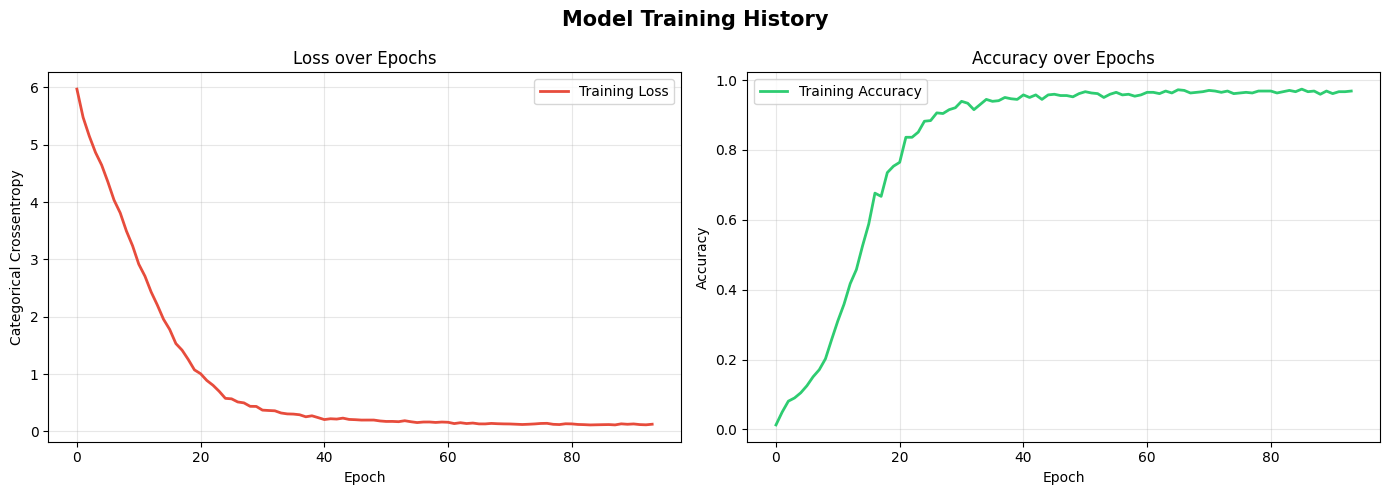

Plot saved as training_history.png


In [7]:
fig, axes=plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Training History', fontsize=15, fontweight='bold')

# Loss
axes[0].plot(history.history['loss'], color='#e74c3c', linewidth=2, label='Training Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Categorical Crossentropy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'], color='#2ecc71', linewidth=2, label='Training Accuracy')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as training_history.png')

## Step 8: Prediction Functions

In [8]:
def predict_next_word(seed_text, top_k=5):
    """
    Predict the top-k most likely next words for a given seed text.
    Returns list of (word, probability) tuples.
    """
    token_list=tokenizer.texts_to_sequences([seed_text.lower()])[0]
    token_list=pad_sequences([token_list], maxlen=max_seq_len - 1, padding='pre')

    predictions=model.predict(token_list, verbose=0)[0]

    # Get top-k predictions
    top_indices=np.argsort(predictions)[::-1][:top_k]
    results=[]
    for idx in top_indices:
        word = index_word.get(idx, '<UNK>')
        prob = predictions[idx]
        results.append((word, float(prob)))
    return results


def generate_text(seed_text, num_words=10, temperature=1.0):
    """
    Generate text by predicting word-by-word.
    temperature > 1 → more creative/random
    temperature < 1 → more conservative/deterministic
    """
    generated=seed_text
    current_text=seed_text

    for _ in range(num_words):
        token_list=tokenizer.texts_to_sequences([current_text.lower()])[0]
        token_list=pad_sequences([token_list], maxlen=max_seq_len - 1, padding='pre')

        predictions=model.predict(token_list, verbose=0)[0]

        # Apply temperature
        predictions=np.log(predictions + 1e-10) / temperature
        predictions=np.exp(predictions)
        predictions=predictions / np.sum(predictions)

        # Sample from distribution
        predicted_index=np.random.choice(len(predictions), p=predictions)
        predicted_word=index_word.get(predicted_index, '')

        if not predicted_word or predicted_word == '<OOV>':
            continue

        generated     += ' ' + predicted_word
        current_text   = generated

    return generated


#  Quick test
test_phrases=[
    "deep learning is",
    "the sun",
    "artificial intelligence",
    "neural networks are"
]

print('=' * 60)
print('NEXT WORD PREDICTIONS (Top 5)')
print('=' * 60)
for phrase in test_phrases:
    preds = predict_next_word(phrase, top_k=5)
    print(f'\nSeed: "{phrase}"')
    for rank, (word, prob) in enumerate(preds, 1):
        bar = '█' * int(prob * 30)
        print(f'  {rank}. {word:<20} {prob:.4f}  {bar}')

NEXT WORD PREDICTIONS (Top 5)

Seed: "deep learning is"
  1. a                    0.9987  █████████████████████████████
  2. subset               0.0004  
  3. foundation           0.0002  
  4. home                 0.0002  
  5. transforming         0.0001  

Seed: "the sun"
  1. rises                0.9947  █████████████████████████████
  2. in                   0.0021  
  3. covers               0.0007  
  4. power                0.0003  
  5. more                 0.0002  

Seed: "artificial intelligence"
  1. is                   0.9984  █████████████████████████████
  2. holds                0.0007  
  3. intelligence         0.0003  
  4. comes                0.0002  
  5. transforming         0.0001  

Seed: "neural networks are"
  1. inspired             0.9963  █████████████████████████████
  2. by                   0.0018  
  3. step                 0.0003  
  4. the                  0.0002  
  5. are                  0.0002  


##  Step 9: Text Generation

In [9]:
print('='*60)
print('TEXT GENERATION')
print('='*60)

seeds=[
    ("deep learning",         10, 0.8),
    ("the human brain",       10, 0.7),
    ("artificial intelligence", 12, 1.0),
    ("the ocean",             10, 0.9),
]

for seed, n_words, temp in seeds:
    generated = generate_text(seed, num_words=n_words, temperature=temp)
    print(f'\nSeed      : "{seed}"')
    print(f' Temperature: {temp}')
    print(f' Generated : "{generated}"')

TEXT GENERATION

Seed      : "deep learning"
 Temperature: 0.8
 Generated : "deep learning is a subset of machine learning that uses neural networks"

Seed      : "the human brain"
 Temperature: 0.7
 Generated : "the human brain contains billions of neurons that communicate through synapses synapses synapses"

Seed      : "artificial intelligence"
 Temperature: 1.0
 Generated : "artificial intelligence is transforming the way we live and work cannot go back to"

Seed      : "the ocean"
 Temperature: 0.9
 Generated : "the ocean covers more than seventy percent of the surface of the"


##  Step 10: Visualize Top Predictions

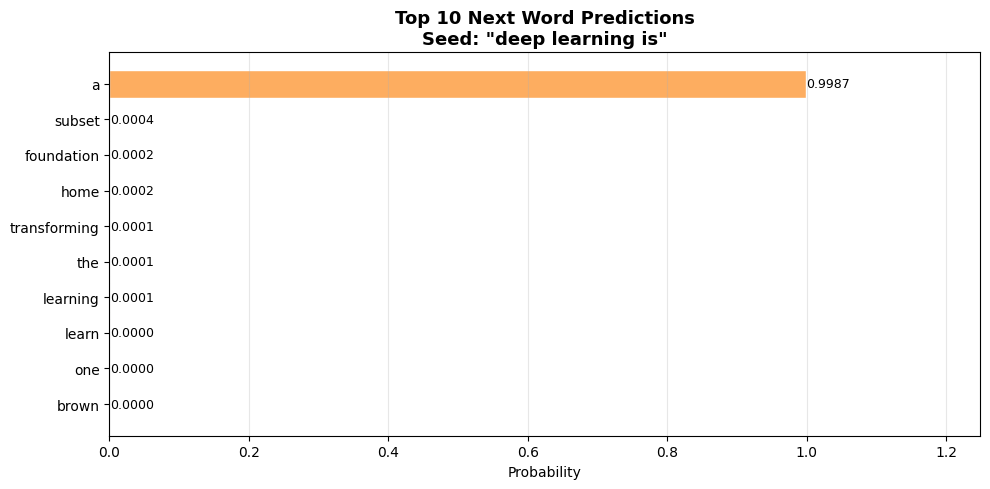

In [10]:
def plot_predictions(seed_text, top_k=10):
    preds=predict_next_word(seed_text, top_k=top_k)
    words=[p[0] for p in preds]
    probs=[p[1] for p in preds]

    colors=plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(words)))

    fig, ax=plt.subplots(figsize=(10, 5))
    bars=ax.barh(words[::-1], probs[::-1], color=colors[::-1], edgecolor='white')

    for bar, prob in zip(bars, probs[::-1]):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{prob:.4f}', va='center', fontsize=9)

    ax.set_title(f'Top {top_k} Next Word Predictions\nSeed: "{seed_text}"',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Probability')
    ax.set_xlim(0, max(probs) * 1.25)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('top_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_predictions("deep learning is", top_k=10)

##  Step 11: Interactive Prediction Widget

In [11]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Widgets
seed_input=widgets.Text(
    value='deep learning',
    description='Seed Text:',
    layout=widgets.Layout(width='400px')
)
top_k_slider=widgets.IntSlider(
    value=5, min=1, max=15, step=1,
    description='Top K:',
    layout=widgets.Layout(width='300px')
)
num_words_slider=widgets.IntSlider(
    value=10, min=5, max=30, step=1,
    description='Gen Words:',
    layout=widgets.Layout(width='300px')
)
temp_slider=widgets.FloatSlider(
    value=0.8, min=0.1, max=2.0, step=0.1,
    description='Temperature:',
    layout=widgets.Layout(width='300px')
)
output_area=widgets.Output()

predict_btn=widgets.Button(description='Predict Next Words', button_style='primary',
                               layout=widgets.Layout(width='200px'))
generate_btn=widgets.Button(description='Generate Text',      button_style='success',
                               layout=widgets.Layout(width='200px'))

def on_predict(b):
    with output_area:
        clear_output()
        preds = predict_next_word(seed_input.value, top_k=top_k_slider.value)
        print(f'\n Seed: "{seed_input.value}"')
        print('-' * 40)
        for rank, (word, prob) in enumerate(preds, 1):
            bar = '█' * int(prob * 40)
            print(f'{rank:>2}. {word:<20} {prob:.4f}  {bar}')

def on_generate(b):
    with output_area:
        clear_output()
        result = generate_text(
            seed_input.value,
            num_words=num_words_slider.value,
            temperature=temp_slider.value
        )
        print(f'\n Generated Text:')
        print('-' * 40)
        print(f'  "{result}"')

predict_btn.on_click(on_predict)
generate_btn.on_click(on_generate)

display(
    widgets.VBox([
        widgets.HTML('<h3>Interactive Next Word Predictor</h3>'),
        seed_input,
        widgets.HBox([top_k_slider, num_words_slider, temp_slider]),
        widgets.HBox([predict_btn, generate_btn]),
        output_area
    ])
)

##  Step 12: Save & Load the Model

In [12]:
import pickle

#Save model
model.save('next_word_lstm_model.h5')
print('Model saved as next_word_lstm_model.h5')

# Save tokenizer
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print('Tokenizer saved as tokenizer.pkl')

# Save metadata
metadata={
    'vocab_size':   vocab_size,
    'max_seq_len':  max_seq_len,
    'embedding_dim': EMBEDDING_DIM,
}
with open('model_metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)
print('Metadata saved as model_metadata.pkl')

# Reload & verify
loaded_model=load_model('next_word_lstm_model.h5')
with open('tokenizer.pkl', 'rb') as f:
    loaded_tokenizer = pickle.load(f)

print('\nModel reloaded successfully!')
print('Test prediction after reload:')
token_list=loaded_tokenizer.texts_to_sequences(['the future of'])[0]
token_list=pad_sequences([token_list], maxlen=max_seq_len - 1, padding='pre')
preds=loaded_model.predict(token_list, verbose=0)[0]
top_idx=np.argsort(preds)[::-1][:3]
for idx in top_idx:
    print(f'  → {index_word.get(idx,"?")}  ({preds[idx]:.4f})')

Model saved as next_word_lstm_model.h5
Tokenizer saved as tokenizer.pkl
Metadata saved as model_metadata.pkl



Model reloaded successfully!
Test prediction after reload:
  → artificial  (0.9967)
  → organisms  (0.0005)
  → life  (0.0005)


## Step 13: Model Evaluation Summary

In [13]:
#  Final evaluation
loss, accuracy = model.evaluate(X, y, verbose=0)

print('=' * 50)
print('FINAL MODEL EVALUATION')
print('=' * 50)
print(f'  Loss          : {loss:.4f}')
print(f'  Accuracy      : {accuracy:.4f} ({accuracy*100:.2f}%)')
print(f'  Vocab Size    : {vocab_size}')
print(f'  Max Seq Length: {max_seq_len}')
print(f'  Training Seqs : {len(X)}')
print(f'  Parameters    : {model.count_params():,}')
print('=' * 50)

print('\nTips to improve:')
print('• Add more corpus text for better coverage')
print('• Increase LSTM_UNITS for more capacity')
print('• Use pre-trained embeddings (GloVe/Word2Vec)')
print('• Try Transformer architecture for large datasets')

FINAL MODEL EVALUATION
  Loss          : 0.0884
  Accuracy      : 0.9706 (97.06%)
  Vocab Size    : 340
  Max Seq Length: 15
  Training Seqs : 544
  Parameters    : 1,216,292

Tips to improve:
• Add more corpus text for better coverage
• Increase LSTM_UNITS for more capacity
• Use pre-trained embeddings (GloVe/Word2Vec)
• Try Transformer architecture for large datasets
